# Statement of AI use
AI was used to either fix or improve codes. 

# Introduction
# Steam Games Analytics 
## Project Goal
The goal of this project is to analyse Steam video game data to better understand trends in pricing, popularity, reviews, and game releases

The project investigates questions such as:
- What price range are most common in Steam games?
- Does higher game price correlate with better review scores?
- How have game releases changed over time?
- Which genre are most common?

## How to run this notebook
1. Install required libraries
   - pandas
   - matplotlib
   - seaborn
   - requests
   - python-dotenv
   - kagglehub
  
2. Download Steam game dataset from:
https://www.kaggle.com/datasets/fronkongames/steam-games-dataset

3. Place the dataset CSV file in the same folder as this noteook

4. Run all notebook cells from top to bottom

## Files produced:
- exports/raw_steam_data.csv
- exports/cleaned_steam_data.csv
- exports/summary_statistics.csv

# Import libraries and Load dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import numpy as np
import os
import kagglehub

from IPython.display import display

# Download dataset
path = kagglehub.dataset_download("fronkongames/steam-games-dataset")

df = pd.read_csv(f"{path}/games.csv")

display(df.head())
display(df.shape)

print(os.listdir(path))

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


(122611, 39)

['games.csv', 'games.json']


# 

In [3]:
os.makedirs("exports", exist_ok=True)
df.to_csv("exports/raw_steam_data.csv", index=False)
print("Raw data has been exported.")

Raw data has been exported.


# Data cleaning and Transformation

In [7]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna(subset=["Price", "Metacritic score"])

# Clean column names
df.columns = df.columns.str.strip()

# Parse dates
df["release_date"] = pd.to_datetime(
    df["Release date"],
    format="%b %d, %Y",
    errors="coerce"
)

# Year extraction
df["release_year"] = df["release_date"].dt.year

# Numeric safety
df["Positive"] = pd.to_numeric(df["Positive"], errors="coerce")
df["Negative"] = pd.to_numeric(df["Negative"], errors="coerce")

df["total_reviews"] = df["Positive"].fillna(0) + df["Negative"].fillna(0)

display(df.head())

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies,release_date,total_reviews,release_year
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaT,0,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN,NaT,255,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN,NaT,24,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaT,0,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaT,0,NaN


# Summary Statistics

In [9]:
summary_stats = df[[
    "Price",
    "Metacritic score",
    "Positive",
    "Negative",
    "total_reviews"
]].describe()

display(summary_stats)

,Price,Metacritic score,Positive,Negative,total_reviews
count,122604.000000,122604.000000,1.226040e+05,1.226040e+05,1.226040e+05
mean,18.354711,2.565088,1.045046e+03,1.692071e+02,1.214253e+03
std,28.859460,13.660935,2.809253e+04,5.374798e+03,3.263772e+04
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000,0.000000,5.000000e+00,1.000000e+00,7.000000e+00
75%,40.000000,0.000000,3.700000e+01,1.000000e+01,4.900000e+01
max,100.000000,97.000000,7.642084e+06,1.173003e+06,8.815087e+06


# Visualisation 1 - Price distribution

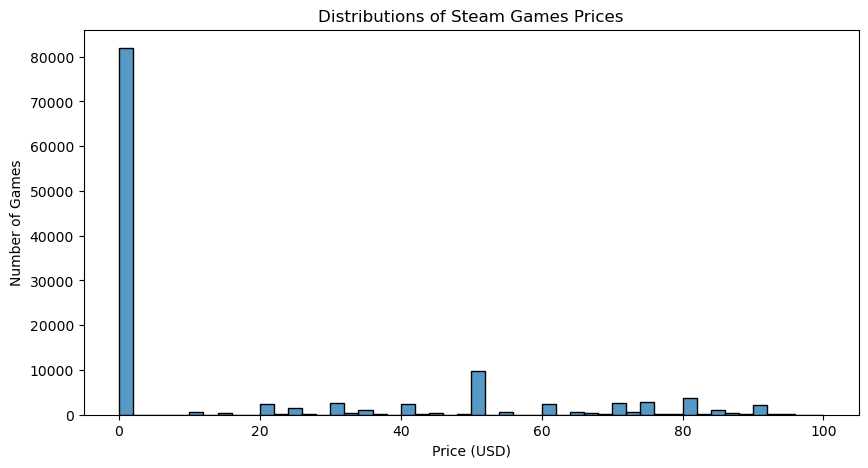

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df["Price"], bins=50)

plt.title("Distributions of Steam Games Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Games")

plt.show()

# Visualisation 2 - Price vs Metacritic Score

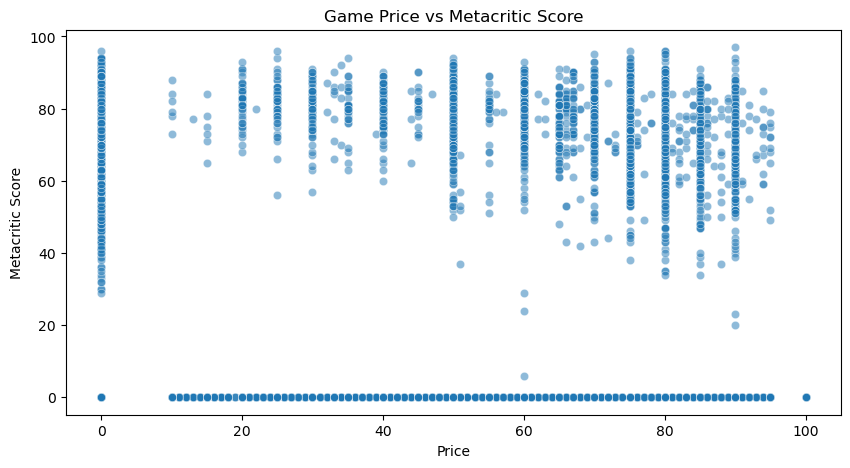

In [13]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="Price",
    y="Metacritic score",
    alpha=0.5
)

plt.title("Game Price vs Metacritic Score")
plt.xlabel("Price")
plt.ylabel("Metacritic Score")

plt.show()

# Visualisation 3 - Game Releases Over Time

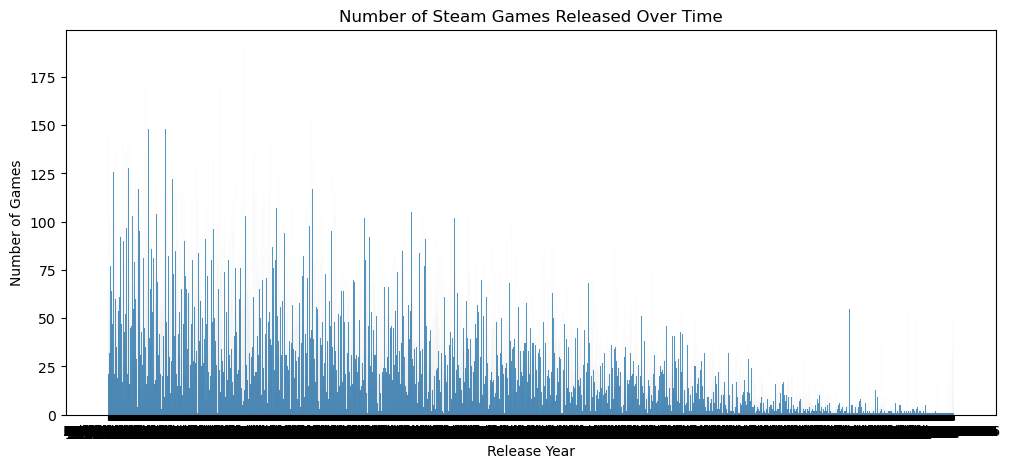

In [17]:
plt.figure(figsize=(12,5))

sns.histplot(df["Name"].dropna(), bins=30)

plt.title("Number of Steam Games Released Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Games")

plt.show()

# Correlation Analysis

In [19]:
correlation = df[[
    "Price",
    "Metacritic score",
    "Positive",
    "Negative",
    "total_reviews"
]].corr()

display(correlation)

,Price,Metacritic score,Positive,Negative,total_reviews
Price,1.000000,0.201785,0.027593,0.016685,0.026498
Metacritic score,0.201785,1.000000,0.108569,0.068667,0.104757
Positive,0.027593,0.108569,1.000000,0.818396,0.995512
Negative,0.016685,0.068667,0.818396,1.000000,0.869105
total_reviews,0.026498,0.104757,0.995512,0.869105,1.000000


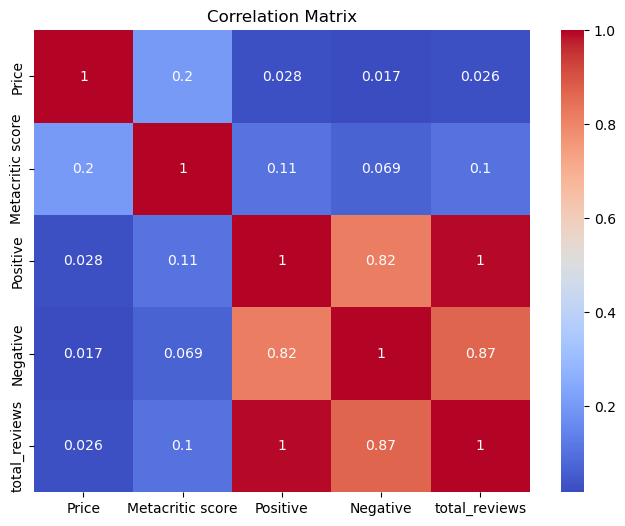

In [21]:
# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# Export Cleaned Data & Results

In [23]:
df.to_csv("exports/cleaned_steam_data.csv", index=False)

summary_stats.to_csv("exports/summary_statistics.csv")

print("Cleaned data and results exported")

Cleaned data and results exported


# Conclusion
This project analyzed Steam video game data to explore pricing, popularity, and review trends.

Key findings:
- Most Steam games are low-priced or free-to-play.
- Higher prices do not necessarily correspond to higher Metacritic scores.
- The number of games released on Steam has increased significantly over time.
- Review counts show stronger relationships with popularity than price alone.

The analysis demonstrates how data science techniques such as cleaning, visualization, statistical analysis, and API integration can be used to better understand trends in the gaming industry.